# Notebook 02: Exploratory Data Analysis
## Wearable-Enhanced Insurance Underwriting — NHANES 2003-2004

**Author:** Lubaba Hassan | 22097014D | PolyU Data Science and Analytics

This notebook performs EDA on the three scenario datasets prepared in Notebook 01:
1. Data overview and class distribution
2. Feature distributions by risk class
3. Correlation analysis
4. Feature-target relationships (univariate)
5. Scenario comparison (A vs B vs C)
6. Key findings summary for modelling decisions

**Three-class label (Composite Underwriting Risk):**
- **Low (0):** FRS < 10% and no diabetes, hypertension, or severe obesity
- **Intermediate (1):** FRS 10-19% OR severe obesity OR hypertension alone
- **High (2):** FRS ≥ 20% OR diabetes OR hypertension + additional risk factor

## 1. Imports and Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = '../data/processed/'
FIGURES_PATH = '../reports/figures/'

# Load scenario datasets
scenario_a = pd.read_csv(DATA_PATH + 'scenario_a.csv')
scenario_b = pd.read_csv(DATA_PATH + 'scenario_b.csv')
scenario_c = pd.read_csv(DATA_PATH + 'scenario_c.csv')

print('Datasets loaded:')
print(f'  Scenario A (Traditional):          {scenario_a.shape}')
print(f'  Scenario B (Traditional + Wearable): {scenario_b.shape}')
print(f'  Scenario C (Wearable only):         {scenario_c.shape}')

Datasets loaded:
  Scenario A (Traditional):          (3388, 20)
  Scenario B (Traditional + Wearable): (1887, 27)
  Scenario C (Wearable only):         (1887, 14)


In [23]:
# Define feature groups
TRADITIONAL_FEATURES = [
    'age', 'male', 'bmi', 'waist_cm',
    'systolic_bp', 'diastolic_bp',
    'total_cholesterol', 'hdl_cholesterol',
    'ever_smoker', 'self_rated_health',
    'daily_activity_level', 'high_chol_told',
    'bp_hypertension_measured'
]
WEARABLE_FEATURES = [
    'total_met_hours', 'mean_met', 'total_activities',
    'moderate_count', 'vigorous_count', 'vigorous_ratio',
    'activity_category'
]
LABEL_COL = 'risk_class'
LABEL_NAMES = {0: 'Low', 1: 'Intermediate', 2: 'High'}
LABEL_COLORS = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
CLASS_ORDER = ['Low', 'Intermediate', 'High']

print('Feature groups defined.')
print(f'  Traditional: {len(TRADITIONAL_FEATURES)} features')
print(f'  Wearable:    {len(WEARABLE_FEATURES)} features')

Feature groups defined.
  Traditional: 13 features
  Wearable:    7 features


## 2. Data Overview

In [24]:
# Scenario A overview
print('SCENARIO A — Traditional Features Only')
print('=' * 50)
print(f'Shape: {scenario_a.shape}')
print(f'\nData types:')
print(scenario_a[TRADITIONAL_FEATURES].dtypes)
print(f'\nDescriptive statistics:')
print(scenario_a[TRADITIONAL_FEATURES].describe().round(2))

SCENARIO A — Traditional Features Only
Shape: (3388, 20)

Data types:
age                         float64
male                        float64
bmi                         float64
waist_cm                    float64
systolic_bp                 float64
diastolic_bp                float64
total_cholesterol           float64
hdl_cholesterol             float64
ever_smoker                 float64
self_rated_health           float64
daily_activity_level        float64
high_chol_told              float64
bp_hypertension_measured    float64
dtype: object

Descriptive statistics:
          age    male     bmi  waist_cm  systolic_bp  diastolic_bp  \
count 3388.00 3388.00 3388.00   3388.00      3388.00       3388.00   
mean    55.98    0.50   28.52     99.12       129.29         70.46   
std     16.39    0.50    5.67     13.78        21.93         14.08   
min     30.00    0.00   14.70     61.80        79.00          0.00   
25%     42.00    0.00   24.60     89.90       114.00         63.83   
50%

In [25]:
# Scenario B overview (additional wearable features)
print('SCENARIO B — Wearable Features (additional to traditional)')
print('=' * 50)
print(f'Shape: {scenario_b.shape}')
print(f'\nWearable feature statistics:')
print(scenario_b[WEARABLE_FEATURES].describe().round(2))

SCENARIO B — Wearable Features (additional to traditional)
Shape: (1887, 27)

Wearable feature statistics:
       total_met_hours  mean_met  total_activities  moderate_count  \
count          1887.00   1887.00           1887.00         1887.00   
mean             10.53      4.76              2.10            1.47   
std               9.59      1.51              1.56            1.08   
min               2.50      2.50              1.00            0.00   
25%               3.50      3.50              1.00            1.00   
50%               7.50      4.38              2.00            1.00   
75%              13.50      5.75              3.00            2.00   
max              94.00     10.00             13.00            8.00   

       vigorous_count  vigorous_ratio  activity_category  
count         1887.00         1887.00            1887.00  
mean             0.62            0.24               0.69  
std              1.05            0.35               0.79  
min              0.00     

## 3. Class Distribution Analysis

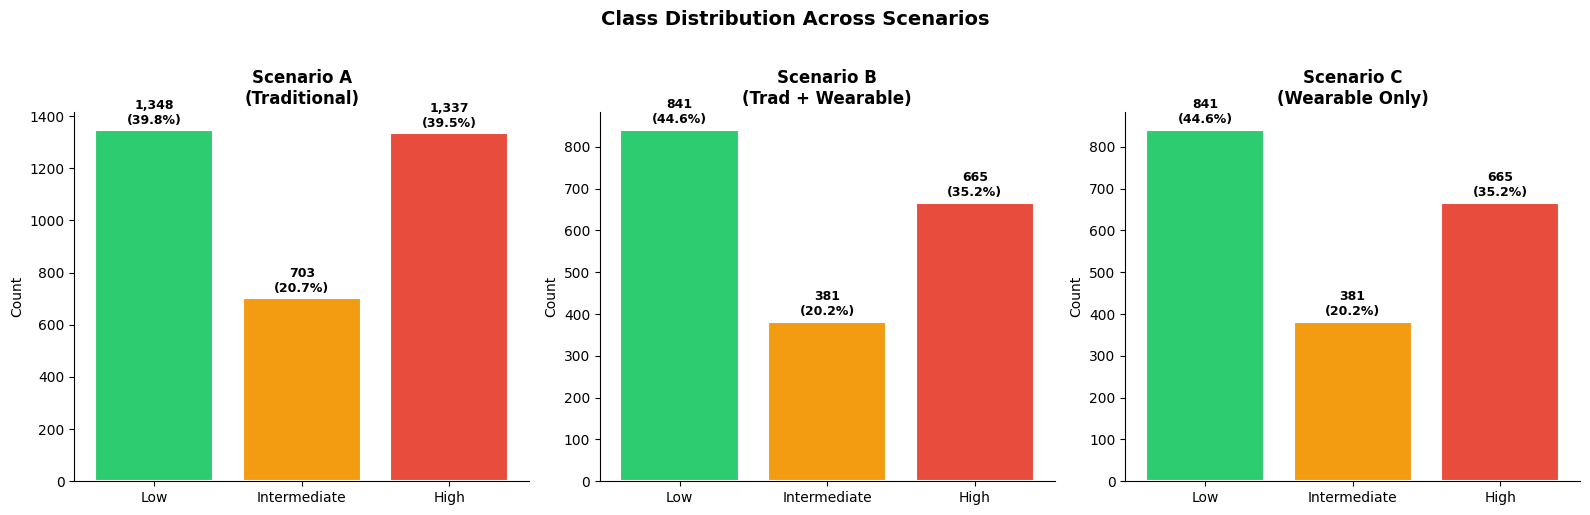

Figure saved.


In [26]:
# Class distribution comparison across scenarios
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (scen, title) in zip(axes, [
    (scenario_a, 'Scenario A\n(Traditional)'),
    (scenario_b, 'Scenario B\n(Trad + Wearable)'),
    (scenario_c, 'Scenario C\n(Wearable Only)')
]):
    counts = scen['risk_class'].value_counts().sort_index()
    colors = [LABEL_COLORS[i] for i in counts.index]
    bars = ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values,
                  color=colors, edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts.values):
        pct = count / len(scen) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
                fontweight='bold', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Class Distribution Across Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

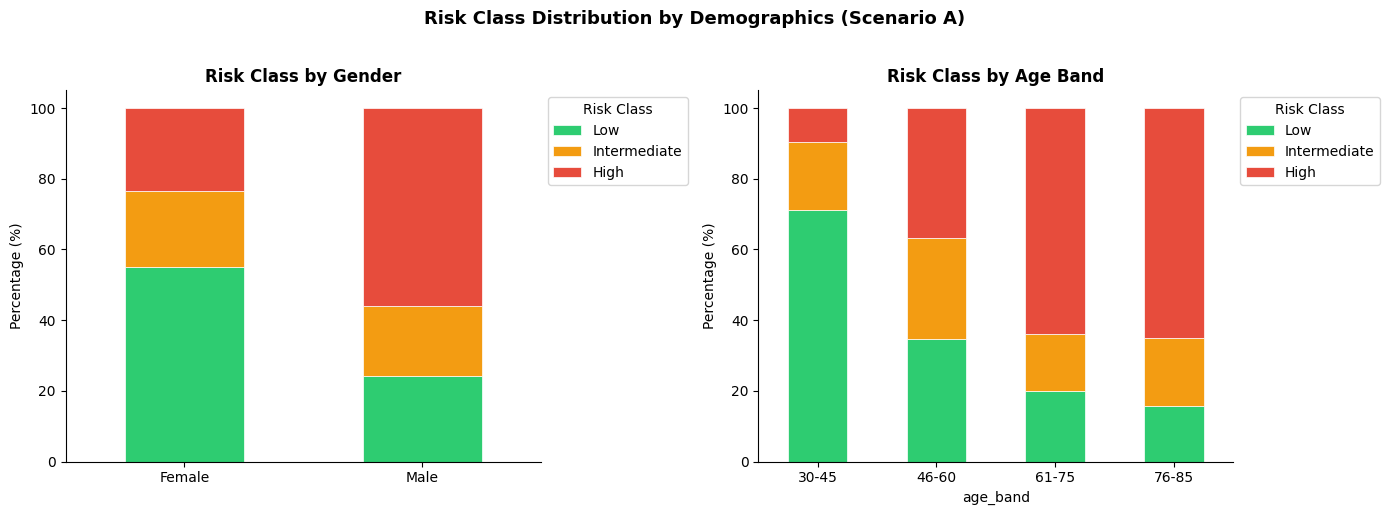

Figure saved.


In [27]:
# Class distribution by demographics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By gender
ax = axes[0]
ct_gender = pd.crosstab(scenario_a['male'], scenario_a['risk_label'], normalize='index') * 100
ct_gender = ct_gender[CLASS_ORDER]
ct_gender.index = ['Female', 'Male']
ct_gender.plot(kind='bar', stacked=True, ax=ax,
               color=[LABEL_COLORS[0], LABEL_COLORS[1], LABEL_COLORS[2]],
               edgecolor='white', linewidth=0.5)
ax.set_title('Risk Class by Gender', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Risk Class', bbox_to_anchor=(1.0, 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# By age band
ax = axes[1]
ct_age = pd.crosstab(scenario_a['age_band'], scenario_a['risk_label'], normalize='index') * 100
ct_age = ct_age[CLASS_ORDER]
ct_age.plot(kind='bar', stacked=True, ax=ax,
            color=[LABEL_COLORS[0], LABEL_COLORS[1], LABEL_COLORS[2]],
            edgecolor='white', linewidth=0.5)
ax.set_title('Risk Class by Age Band', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Risk Class', bbox_to_anchor=(1.0, 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Risk Class Distribution by Demographics (Scenario A)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_class_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4. Feature Distributions by Risk Class

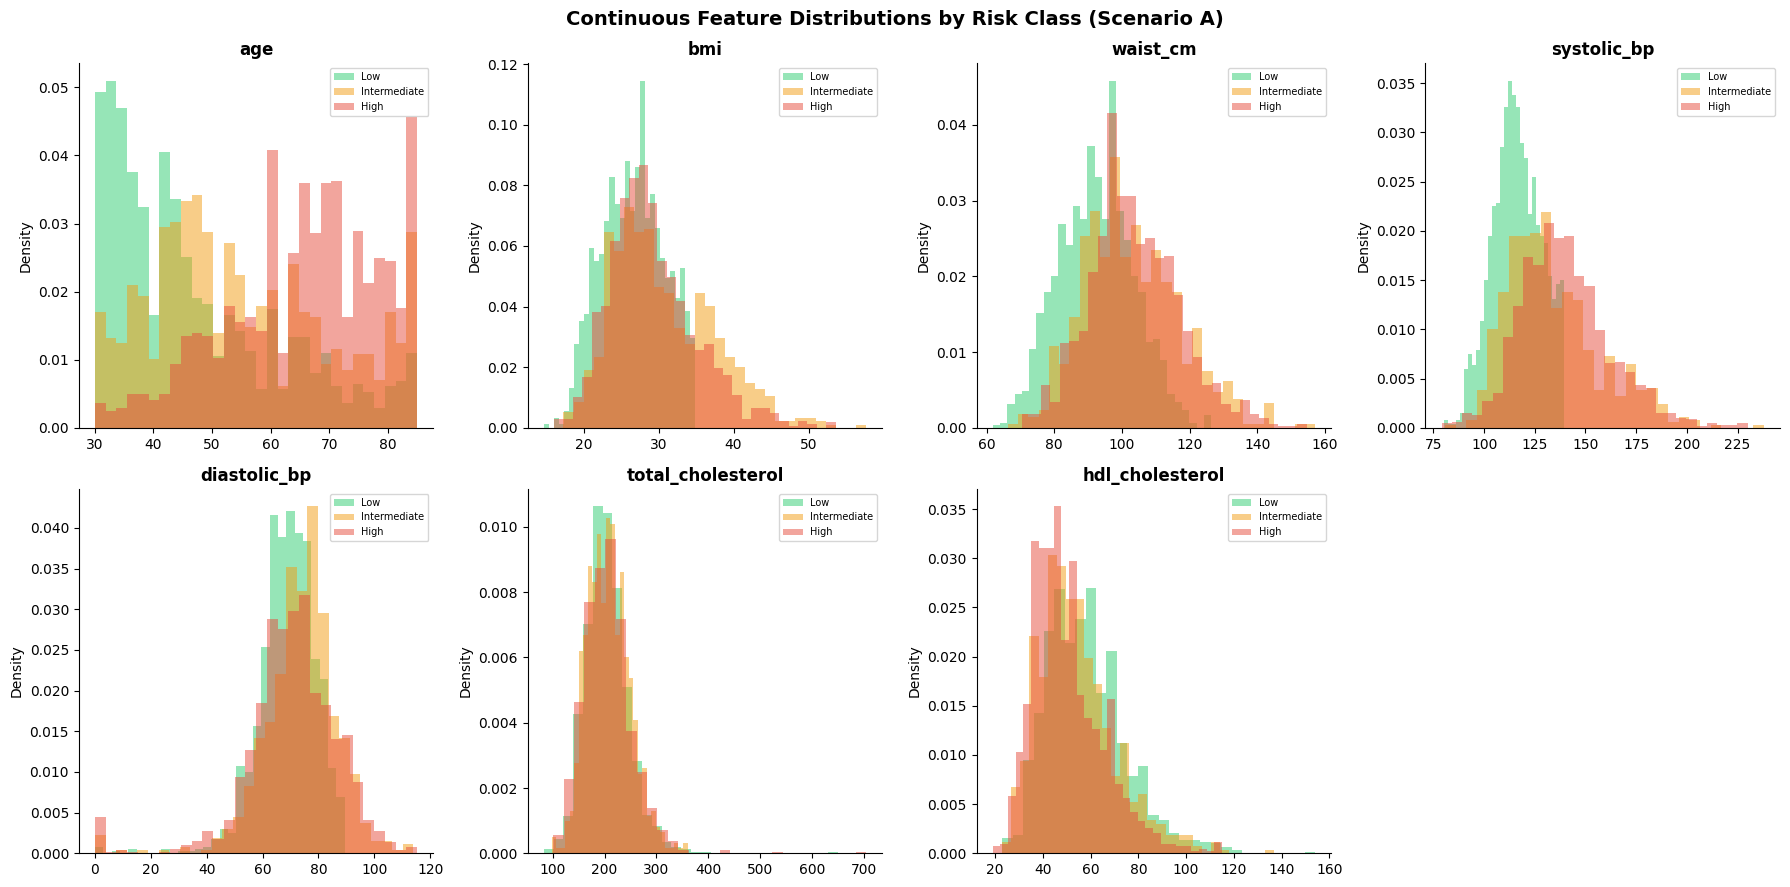

Figure saved.


In [28]:
# Traditional feature distributions by risk class
continuous_features = ['age', 'bmi', 'waist_cm', 'systolic_bp', 'diastolic_bp',
                       'total_cholesterol', 'hdl_cholesterol']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for idx, feat in enumerate(continuous_features):
    ax = axes_flat[idx]
    for cls in [0, 1, 2]:
        data = scenario_a[scenario_a['risk_class'] == cls][feat].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=LABEL_COLORS[cls],
                label=LABEL_NAMES[cls], density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplot
axes_flat[7].set_visible(False)

plt.suptitle('Continuous Feature Distributions by Risk Class (Scenario A)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

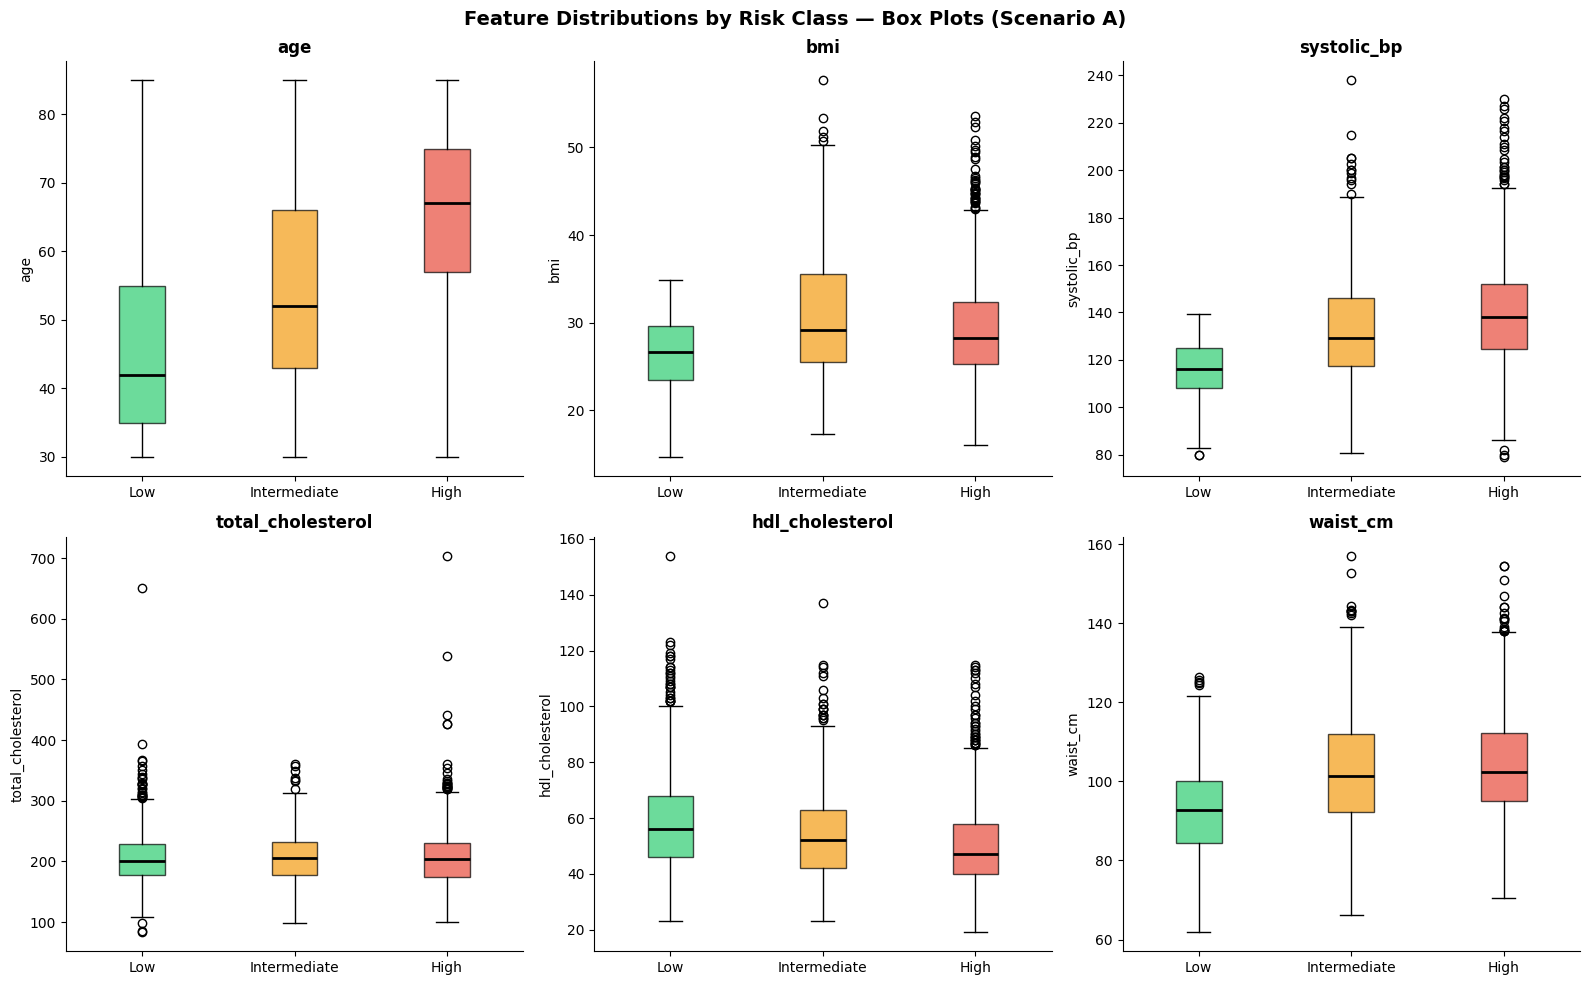

Figure saved.


In [29]:
# Box plots for key features by risk class
box_features = ['age', 'bmi', 'systolic_bp', 'total_cholesterol', 'hdl_cholesterol', 'waist_cm']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), box_features):
    data_to_plot = [scenario_a[scenario_a['risk_class'] == cls][feat].dropna() for cls in [0, 1, 2]]
    bp = ax.boxplot(data_to_plot, labels=CLASS_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(LABEL_COLORS[cls])
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel(feat)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Distributions by Risk Class — Box Plots (Scenario A)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

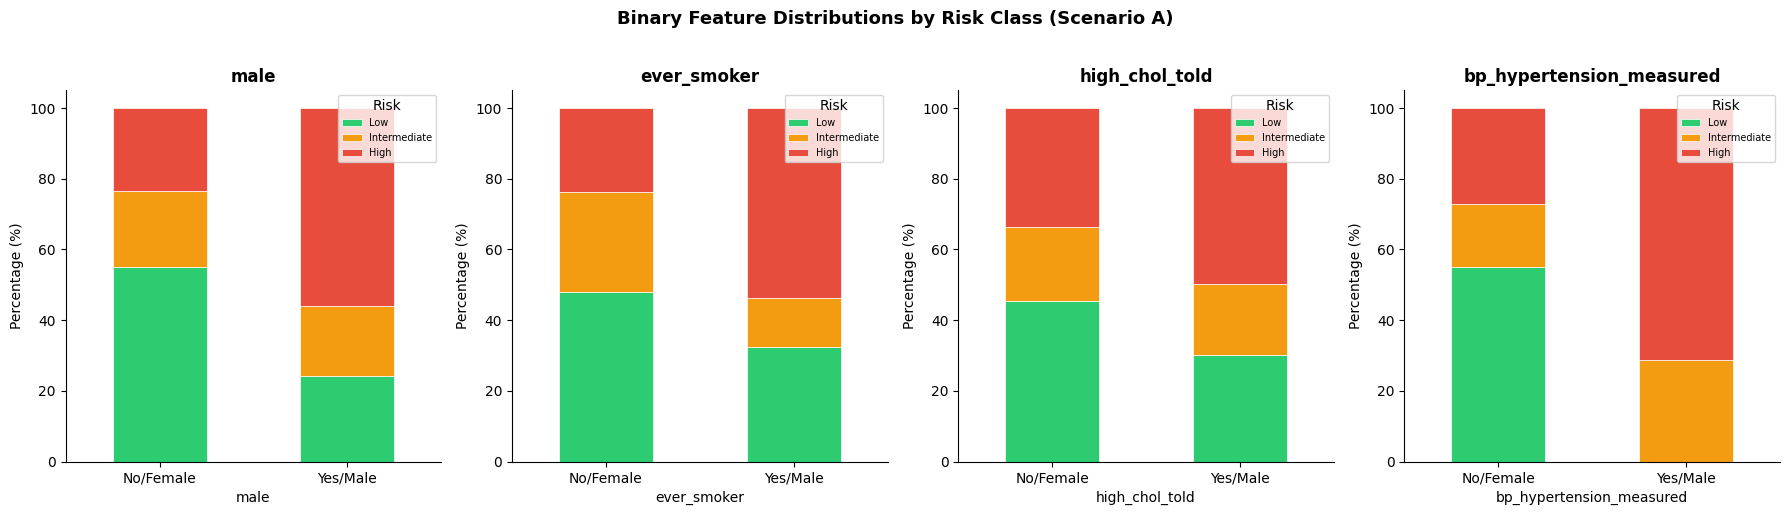

Figure saved.


In [30]:
# Binary/categorical feature distributions by risk class
cat_features = ['male', 'ever_smoker', 'high_chol_told', 'bp_hypertension_measured']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(scenario_a[feat], scenario_a['risk_label'], normalize='index') * 100
    ct = ct[CLASS_ORDER]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[LABEL_COLORS[0], LABEL_COLORS[1], LABEL_COLORS[2]],
            edgecolor='white', linewidth=0.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(['No/Female', 'Yes/Male'] if feat in ['male', 'ever_smoker', 'high_chol_told', 'bp_hypertension_measured'] else ax.get_xticklabels(), rotation=0)
    ax.legend(title='Risk', fontsize=7, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Binary Feature Distributions by Risk Class (Scenario A)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_binary_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

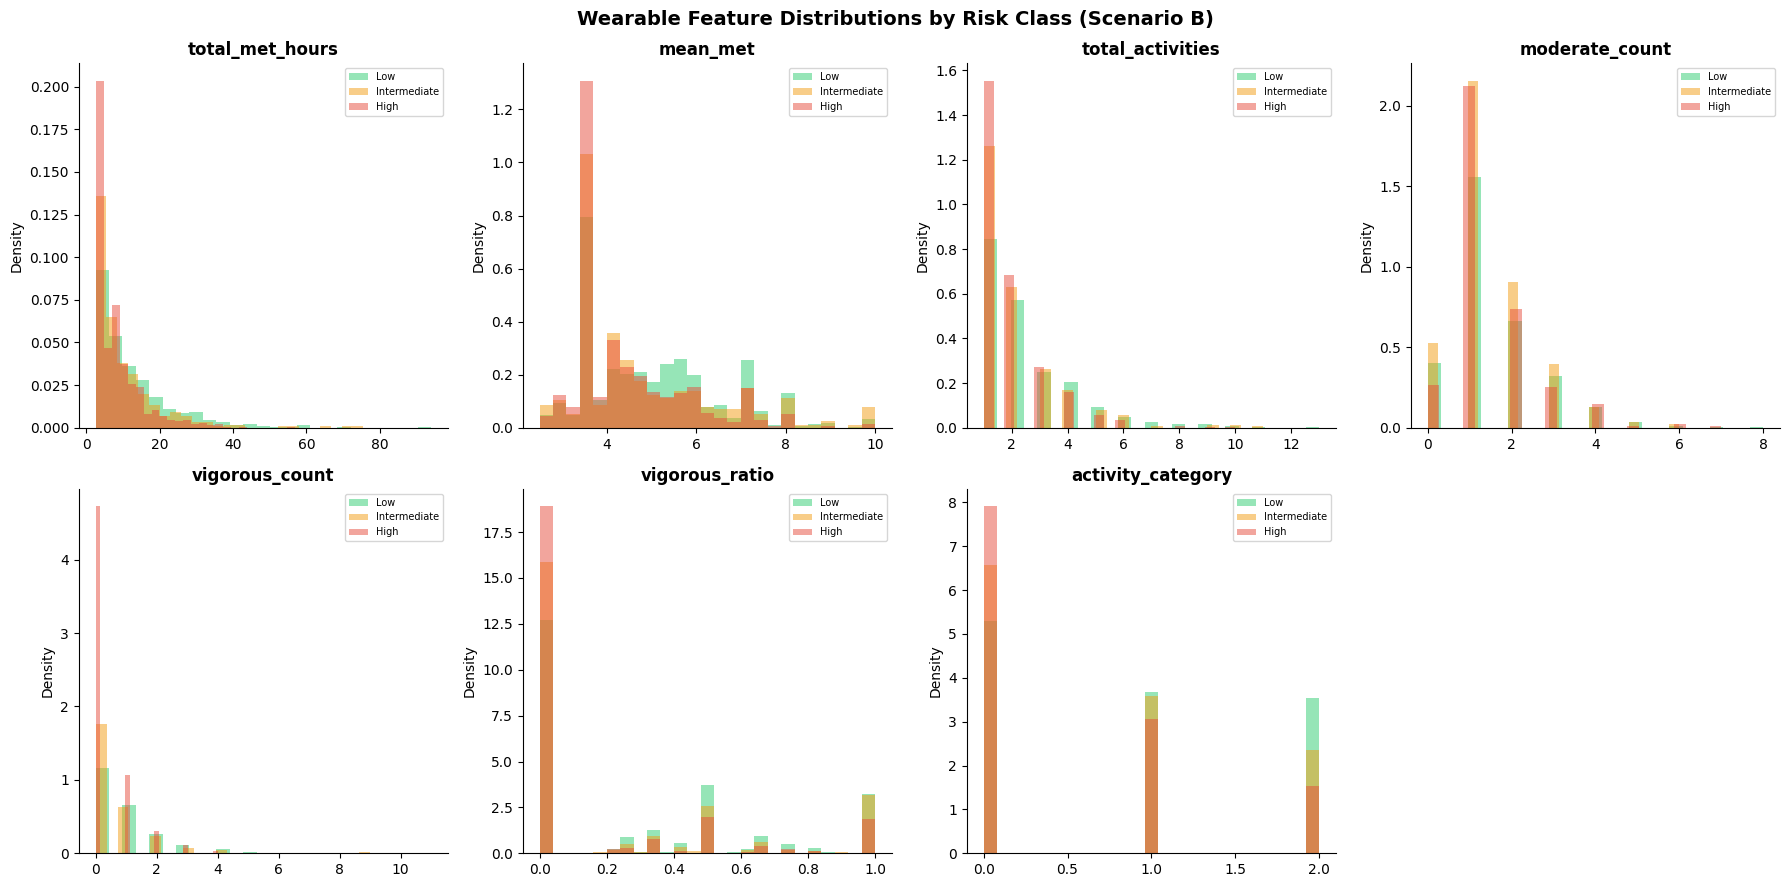

Figure saved.


In [31]:
# Wearable feature distributions by risk class (Scenario B)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for idx, feat in enumerate(WEARABLE_FEATURES):
    ax = axes_flat[idx]
    for cls in [0, 1, 2]:
        data = scenario_b[scenario_b['risk_class'] == cls][feat].dropna()
        ax.hist(data, bins=25, alpha=0.5, color=LABEL_COLORS[cls],
                label=LABEL_NAMES[cls], density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplot
axes_flat[7].set_visible(False)

plt.suptitle('Wearable Feature Distributions by Risk Class (Scenario B)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_wearable_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Correlation Analysis

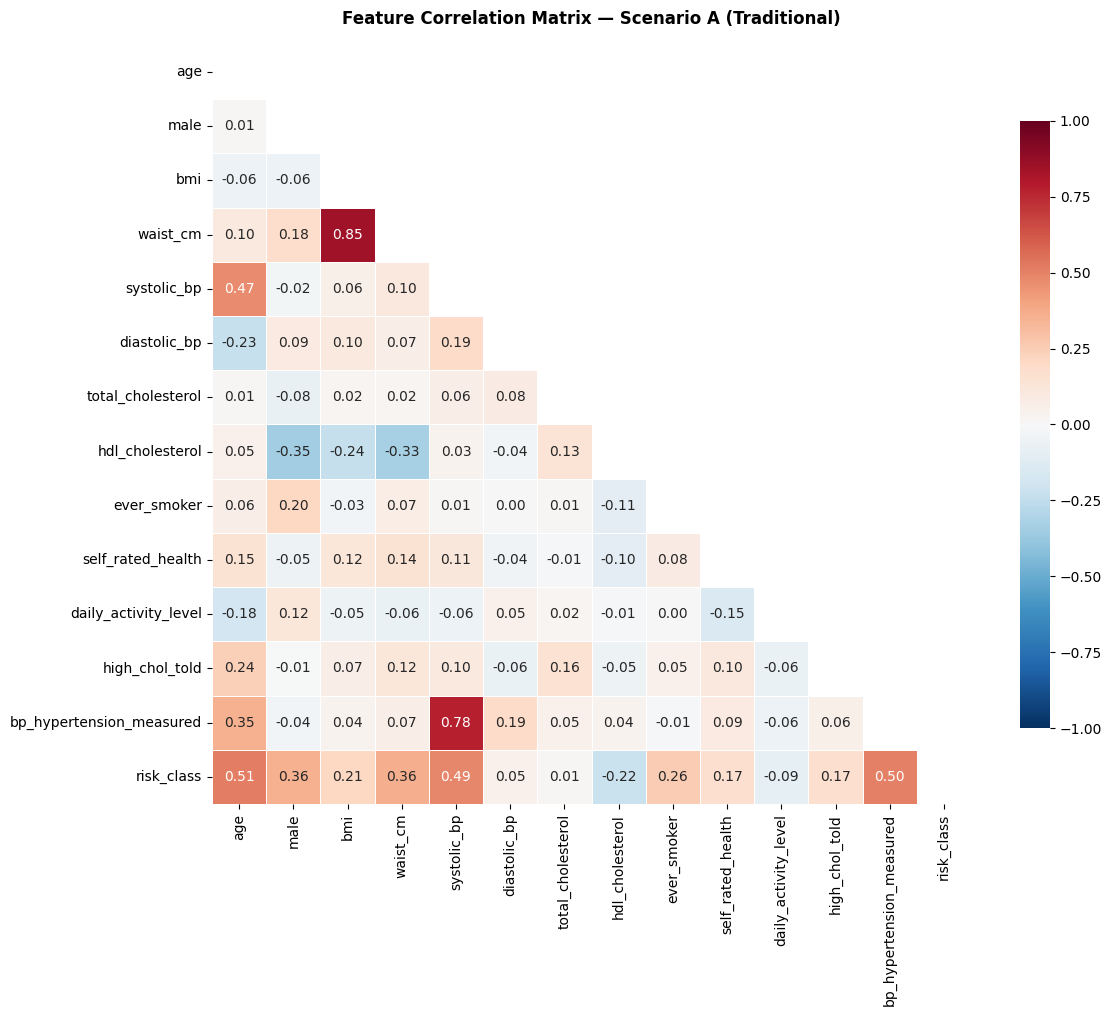

Figure saved.

Top feature correlations with risk_class (Scenario A):
  age                           : +0.512
  bp_hypertension_measured      : +0.500
  systolic_bp                   : +0.486
  waist_cm                      : +0.361
  male                          : +0.356
  ever_smoker                   : +0.256
  hdl_cholesterol               : -0.220
  bmi                           : +0.207
  high_chol_told                : +0.169
  self_rated_health             : +0.168
  daily_activity_level          : -0.093
  diastolic_bp                  : +0.049
  total_cholesterol             : +0.012


In [32]:
# Correlation heatmap — Scenario A (Traditional features)
fig, ax = plt.subplots(figsize=(12, 10))
corr_a = scenario_a[TRADITIONAL_FEATURES + ['risk_class']].corr()
mask = np.triu(np.ones_like(corr_a, dtype=bool))
sns.heatmap(corr_a, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix — Scenario A (Traditional)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_correlation_scenario_a.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

# Highlight strongest correlations with risk_class
print('\nTop feature correlations with risk_class (Scenario A):')
risk_corr = corr_a['risk_class'].drop('risk_class').abs().sort_values(ascending=False)
for feat, val in risk_corr.items():
    direction = '+' if corr_a.loc[feat, 'risk_class'] > 0 else '-'
    print(f'  {feat:30s}: {direction}{val:.3f}')

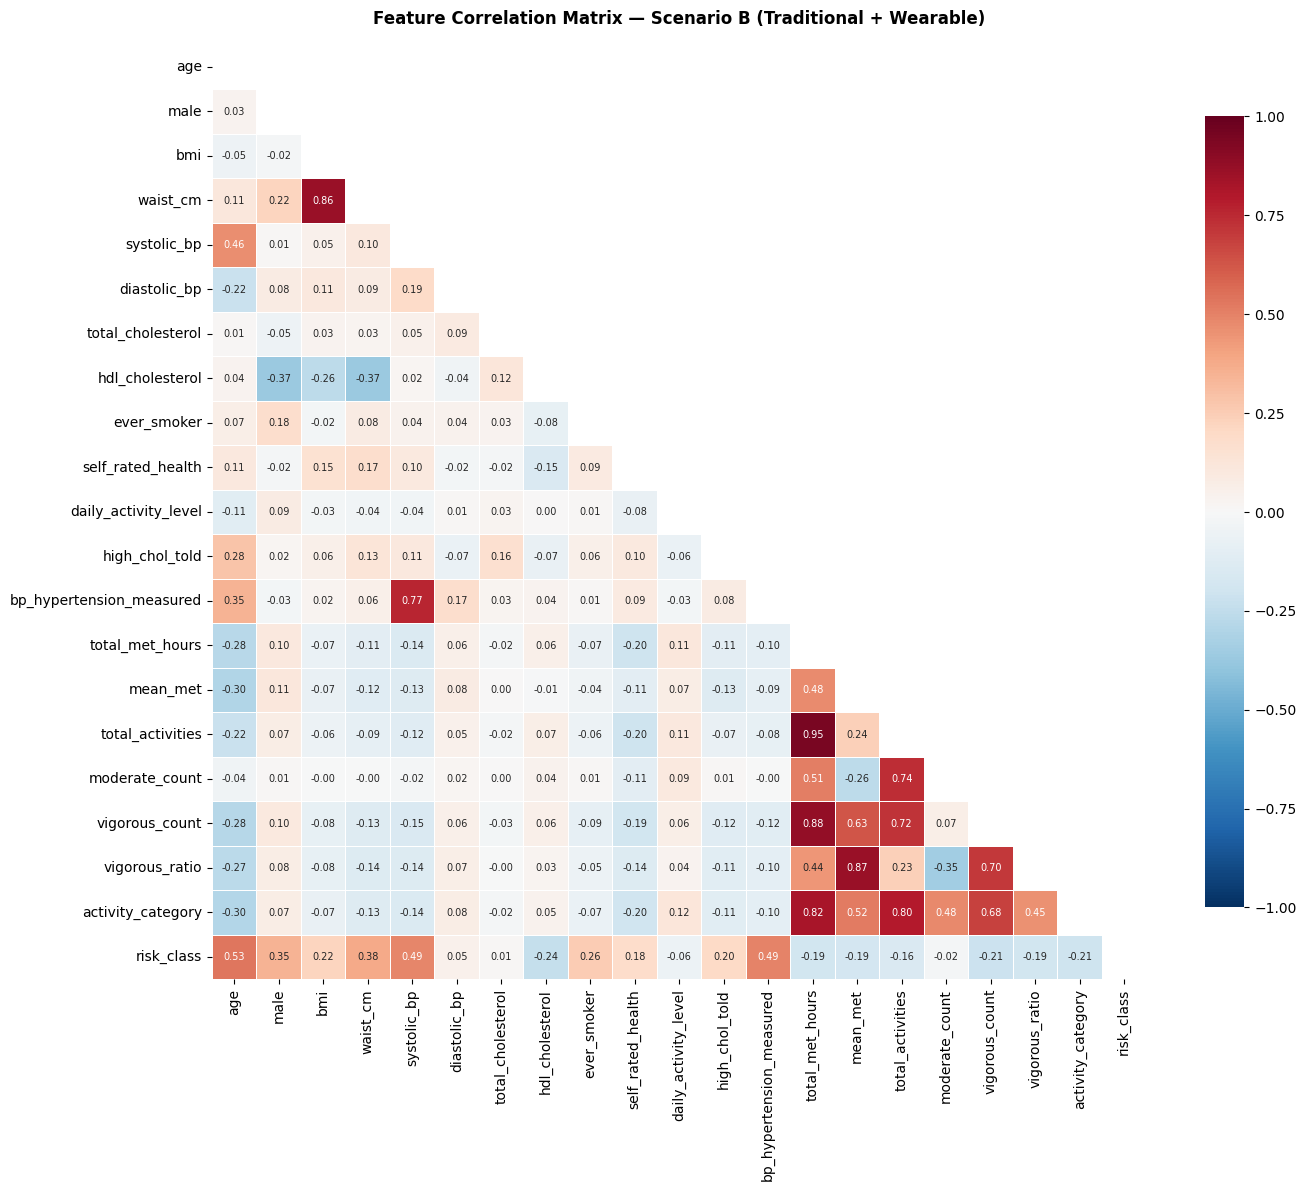

Figure saved.

Feature correlations with risk_class (Scenario B):

  Traditional features:
    age                           : +0.533
    male                          : +0.350
    bmi                           : +0.225
    waist_cm                      : +0.381
    systolic_bp                   : +0.487
    diastolic_bp                  : +0.049
    total_cholesterol             : +0.010
    hdl_cholesterol               : -0.242
    ever_smoker                   : +0.256
    self_rated_health             : +0.180
    daily_activity_level          : -0.056
    high_chol_told                : +0.202
    bp_hypertension_measured      : +0.492

  Wearable features:
    total_met_hours               : -0.193
    mean_met                      : -0.186
    total_activities              : -0.156
    moderate_count                : -0.017
    vigorous_count                : -0.213
    vigorous_ratio                : -0.189
    activity_category             : -0.208


In [33]:
# Correlation heatmap — Scenario B (Traditional + Wearable)
fig, ax = plt.subplots(figsize=(14, 12))
all_features_b = TRADITIONAL_FEATURES + WEARABLE_FEATURES
corr_b = scenario_b[all_features_b + ['risk_class']].corr()
mask = np.triu(np.ones_like(corr_b, dtype=bool))
sns.heatmap(corr_b, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix — Scenario B (Traditional + Wearable)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_correlation_scenario_b.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

# Compare correlations with risk_class: traditional vs wearable
print('\nFeature correlations with risk_class (Scenario B):')
risk_corr_b = corr_b['risk_class'].drop('risk_class')
print('\n  Traditional features:')
for feat in TRADITIONAL_FEATURES:
    val = risk_corr_b[feat]
    print(f'    {feat:30s}: {val:+.3f}')
print('\n  Wearable features:')
for feat in WEARABLE_FEATURES:
    val = risk_corr_b[feat]
    print(f'    {feat:30s}: {val:+.3f}')

## 6. Feature-Target Relationships

In [34]:
# Mean feature values by risk class (Scenario A)
print('MEAN FEATURE VALUES BY RISK CLASS (Scenario A)')
print('=' * 70)
means = scenario_a.groupby('risk_label')[TRADITIONAL_FEATURES].mean()
means = means.reindex(CLASS_ORDER)
print(means.round(2).T.to_string())

print('\n\nMEAN WEARABLE FEATURE VALUES BY RISK CLASS (Scenario B)')
print('=' * 70)
means_w = scenario_b.groupby('risk_label')[WEARABLE_FEATURES].mean()
means_w = means_w.reindex(CLASS_ORDER)
print(means_w.round(2).T.to_string())

MEAN FEATURE VALUES BY RISK CLASS (Scenario A)
risk_label                  Low  Intermediate   High
age                       46.78         55.22  65.65
male                       0.30          0.48   0.70
bmi                       26.64         30.67  29.27
waist_cm                  92.55        102.96 103.73
systolic_bp              116.05        134.34 139.98
diastolic_bp              68.93         73.38  70.46
total_cholesterol        204.81        208.10 206.03
hdl_cholesterol           58.38         54.30  50.32
ever_smoker                0.42          0.35   0.71
self_rated_health          2.65          2.82   3.03
daily_activity_level       2.08          2.05   1.91
high_chol_told             0.28          0.36   0.46
bp_hypertension_measured   0.00          0.38   0.50


MEAN WEARABLE FEATURE VALUES BY RISK CLASS (Scenario B)
risk_label          Low  Intermediate  High
total_met_hours   12.43         10.31  8.27
mean_met           5.03          4.78  4.39
total_activities   2.

In [35]:
# Statistical tests: Kruskal-Wallis for each feature across 3 classes
print('KRUSKAL-WALLIS TEST: Feature differences across risk classes')
print('=' * 70)
print(f'{"Feature":30s} {"H-statistic":>12s} {"p-value":>12s} {"Significant":>12s}')
print('-' * 70)

for feat in TRADITIONAL_FEATURES:
    groups = [scenario_a[scenario_a['risk_class'] == cls][feat].dropna() for cls in [0, 1, 2]]
    if all(len(g) > 0 for g in groups):
        h_stat, p_val = stats.kruskal(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f'{feat:30s} {h_stat:>12.2f} {p_val:>12.2e} {sig:>12s}')

print('\nWearable features (Scenario B):')
print('-' * 70)
for feat in WEARABLE_FEATURES:
    groups = [scenario_b[scenario_b['risk_class'] == cls][feat].dropna() for cls in [0, 1, 2]]
    if all(len(g) > 0 for g in groups):
        h_stat, p_val = stats.kruskal(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f'{feat:30s} {h_stat:>12.2f} {p_val:>12.2e} {sig:>12s}')

print('\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant')

KRUSKAL-WALLIS TEST: Feature differences across risk classes
Feature                         H-statistic      p-value  Significant
----------------------------------------------------------------------
age                                  913.91    3.53e-199          ***
male                                 430.22     3.80e-94          ***
bmi                                  198.66     7.27e-44          ***
waist_cm                             502.90    6.27e-110          ***
systolic_bp                          958.77    6.39e-209          ***
diastolic_bp                          79.71     4.90e-18          ***
total_cholesterol                      3.65     1.61e-01           ns
hdl_cholesterol                      185.12     6.33e-41          ***
ever_smoker                          329.00     3.62e-72          ***
self_rated_health                     94.17     3.56e-21          ***
daily_activity_level                  33.08     6.57e-08          ***
high_chol_told              

total_met_hours                       74.00     8.55e-17          ***
mean_met                              69.75     7.14e-16          ***
total_activities                      46.49     8.02e-11          ***
moderate_count                         0.38     8.25e-01           ns
vigorous_count                       104.16     2.41e-23          ***
vigorous_ratio                        86.74     1.46e-19          ***
activity_category                     80.12     4.01e-18          ***

*** p<0.001, ** p<0.01, * p<0.05, ns = not significant


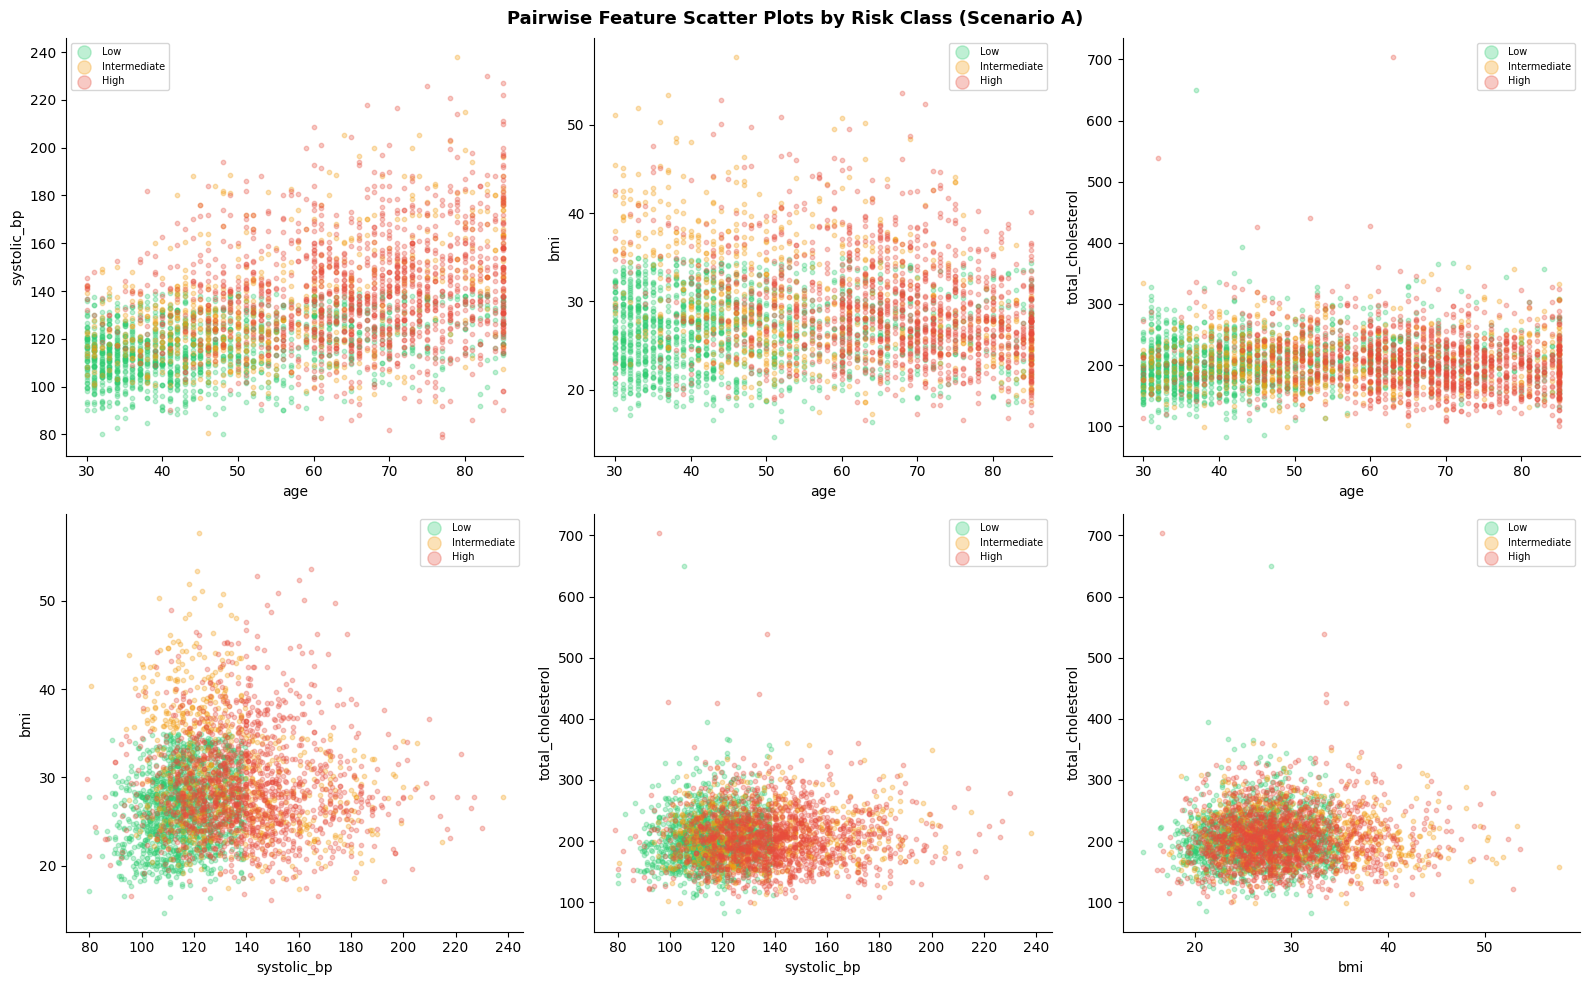

Figure saved.


In [36]:
# Pairwise scatter plots of top discriminating features
top_features = ['age', 'systolic_bp', 'bmi', 'total_cholesterol']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pair_idx = 0
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        if pair_idx >= 6:
            break
        ax = axes.flatten()[pair_idx]
        for cls in [0, 1, 2]:
            mask = scenario_a['risk_class'] == cls
            ax.scatter(scenario_a.loc[mask, top_features[i]],
                       scenario_a.loc[mask, top_features[j]],
                       c=LABEL_COLORS[cls], label=LABEL_NAMES[cls],
                       alpha=0.3, s=10)
        ax.set_xlabel(top_features[i])
        ax.set_ylabel(top_features[j])
        ax.legend(fontsize=7, markerscale=3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        pair_idx += 1

plt.suptitle('Pairwise Feature Scatter Plots by Risk Class (Scenario A)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_scatter_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 7. Wearable Feature Deep Dive

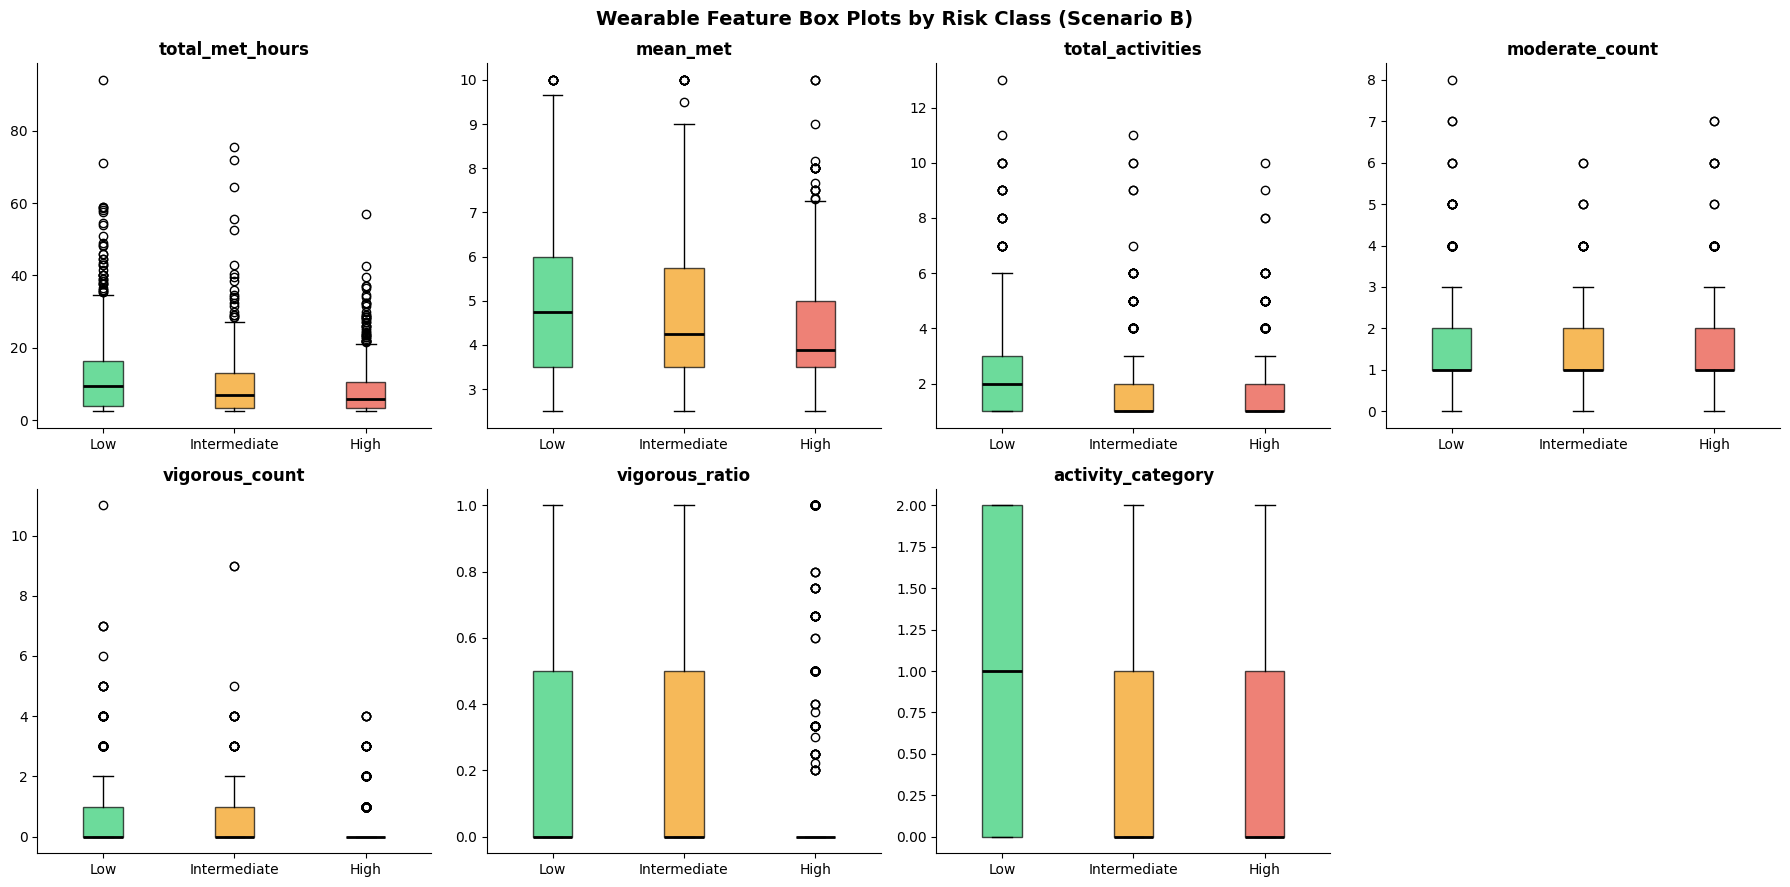

Figure saved.


In [37]:
# Wearable features: box plots by risk class
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for idx, feat in enumerate(WEARABLE_FEATURES):
    ax = axes_flat[idx]
    data_to_plot = [scenario_b[scenario_b['risk_class'] == cls][feat].dropna() for cls in [0, 1, 2]]
    bp = ax.boxplot(data_to_plot, labels=CLASS_ORDER, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(LABEL_COLORS[cls])
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes_flat[7].set_visible(False)

plt.suptitle('Wearable Feature Box Plots by Risk Class (Scenario B)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_wearable_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

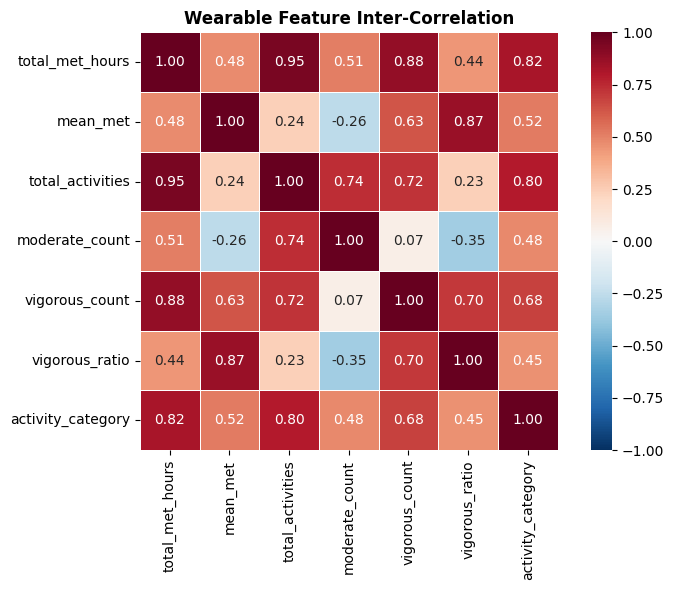

Figure saved.

Highly correlated wearable feature pairs (|r| > 0.7):
  total_met_hours <-> total_activities: r=0.948
  total_met_hours <-> vigorous_count: r=0.879
  total_met_hours <-> activity_category: r=0.821
  mean_met <-> vigorous_ratio: r=0.865
  total_activities <-> moderate_count: r=0.737
  total_activities <-> vigorous_count: r=0.724
  total_activities <-> activity_category: r=0.796
  vigorous_count <-> vigorous_ratio: r=0.704


In [38]:
# Wearable inter-feature correlations
fig, ax = plt.subplots(figsize=(8, 6))
corr_w = scenario_b[WEARABLE_FEATURES].corr()
sns.heatmap(corr_w, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5)
ax.set_title('Wearable Feature Inter-Correlation', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'eda_wearable_intercorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

# Flag highly correlated pairs (potential multicollinearity)
print('\nHighly correlated wearable feature pairs (|r| > 0.7):')
for i in range(len(WEARABLE_FEATURES)):
    for j in range(i+1, len(WEARABLE_FEATURES)):
        r = corr_w.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {WEARABLE_FEATURES[i]} <-> {WEARABLE_FEATURES[j]}: r={r:.3f}')

## 8. Scenario Comparison

In [39]:
# Compare participants in Scenario A vs B
# (B is a subset of A — only those with wearable data)
print('SCENARIO COMPARISON: A vs B')
print('=' * 60)
print(f'Scenario A participants: {len(scenario_a):,}')
print(f'Scenario B participants: {len(scenario_b):,} ({len(scenario_b)/len(scenario_a)*100:.1f}% of A)')
print()

# Check if wearable subsample is representative
print('Demographic comparison (mean values):')
compare_feats = ['age', 'male', 'bmi', 'systolic_bp', 'ever_smoker']
print(f'{"Feature":20s} {"Scenario A":>12s} {"Scenario B":>12s} {"Diff":>8s}')
print('-' * 55)
for feat in compare_feats:
    mean_a = scenario_a[feat].mean()
    mean_b = scenario_b[feat].mean()
    diff = mean_b - mean_a
    print(f'{feat:20s} {mean_a:>12.2f} {mean_b:>12.2f} {diff:>+8.2f}')

print(f'\nClass distribution comparison:')
for cls, name in LABEL_NAMES.items():
    pct_a = (scenario_a['risk_class'] == cls).mean() * 100
    pct_b = (scenario_b['risk_class'] == cls).mean() * 100
    print(f'  {name:15s}: A={pct_a:.1f}%  B={pct_b:.1f}%  diff={pct_b-pct_a:+.1f}%')

SCENARIO COMPARISON: A vs B
Scenario A participants: 3,388
Scenario B participants: 1,887 (55.7% of A)

Demographic comparison (mean values):
Feature                Scenario A   Scenario B     Diff
-------------------------------------------------------
age                         55.98        53.94    -2.03
male                         0.50         0.51    +0.01
bmi                         28.52        28.26    -0.25
systolic_bp                129.29       126.92    -2.37
ever_smoker                  0.52         0.49    -0.04

Class distribution comparison:
  Low            : A=39.8%  B=44.6%  diff=+4.8%
  Intermediate   : A=20.7%  B=20.2%  diff=-0.6%
  High           : A=39.5%  B=35.2%  diff=-4.2%


## 9. Key Findings Summary

In [40]:
print('=' * 70)
print('EDA KEY FINDINGS')
print('=' * 70)

# 1. Class balance
print('\n1. CLASS BALANCE')
for cls, name in LABEL_NAMES.items():
    pct = (scenario_a['risk_class'] == cls).mean() * 100
    print(f'   {name}: {pct:.1f}%')
print('   -> Reasonably balanced; consider stratified splits for training')
print('   -> Intermediate class is smallest; may need class-weighted models')

# 2. Top correlations
print('\n2. TOP FEATURE-TARGET CORRELATIONS (Scenario A)')
corr_target = scenario_a[TRADITIONAL_FEATURES + ['risk_class']].corr()['risk_class'].drop('risk_class')
top5 = corr_target.abs().sort_values(ascending=False).head(5)
for feat in top5.index:
    val = corr_target[feat]
    print(f'   {feat:30s}: {val:+.3f}')

# 3. Wearable signal
print('\n3. WEARABLE FEATURE SIGNAL')
corr_wear = scenario_b[WEARABLE_FEATURES + ['risk_class']].corr()['risk_class'].drop('risk_class')
for feat in WEARABLE_FEATURES:
    val = corr_wear[feat]
    print(f'   {feat:30s}: {val:+.3f}')
print('   -> Wearable features show weaker individual correlations than traditional')
print('   -> Potential value in non-linear interactions (tree-based models)')

# 4. Sample representativeness
print('\n4. WEARABLE SUBSAMPLE REPRESENTATIVENESS')
print(f'   Scenario B is {len(scenario_b)/len(scenario_a)*100:.1f}% of Scenario A')
age_diff = scenario_b['age'].mean() - scenario_a['age'].mean()
print(f'   Mean age difference: {age_diff:+.1f} years')
print('   -> Monitor for selection bias in Scenario B/C results')

# 5. Modelling implications
print('\n5. MODELLING IMPLICATIONS')
print('   - Three-class problem: use macro-averaged metrics (AUC, F1)')
print('   - Intermediate class is smallest: use class weights or SMOTE')
print('   - High multicollinearity in some wearable pairs: tree models preferred')
print('   - Stratified k-fold CV essential for class balance in folds')
print('   - Fairness analysis needed: gender strongly associated with risk class')

EDA KEY FINDINGS

1. CLASS BALANCE
   Low: 39.8%
   Intermediate: 20.7%
   High: 39.5%
   -> Reasonably balanced; consider stratified splits for training
   -> Intermediate class is smallest; may need class-weighted models

2. TOP FEATURE-TARGET CORRELATIONS (Scenario A)
   age                           : +0.512
   bp_hypertension_measured      : +0.500
   systolic_bp                   : +0.486
   waist_cm                      : +0.361
   male                          : +0.356

3. WEARABLE FEATURE SIGNAL
   total_met_hours               : -0.193
   mean_met                      : -0.186
   total_activities              : -0.156
   moderate_count                : -0.017
   vigorous_count                : -0.213
   vigorous_ratio                : -0.189
   activity_category             : -0.208
   -> Wearable features show weaker individual correlations than traditional
   -> Potential value in non-linear interactions (tree-based models)

4. WEARABLE SUBSAMPLE REPRESENTATIVENESS
   Scena

In [41]:
print('Notebook 02 complete.')
print('Next: Run 03_modelling.ipynb to train multi-class classifiers.')

Notebook 02 complete.
Next: Run 03_modelling.ipynb to train multi-class classifiers.
